In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,precision_score,recall_score,classification_report,brier_score_loss,log_loss
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [2]:
df = pd.read_csv('/content/dispute_dataset.csv')

In [3]:
df.shape

(6000, 15)

In [4]:
df.head()

,case_id,reason_code,product_category,payment_method,order_value,time_to_dispute_days,days_remaining_to_respond,delivery_confirmed,communication_logs_present,device_ip_match_score,listing_accuracy_score,customer_prior_disputes,customer_account_age_days,_true_win_prob_debug_only,merchant_won
0,90b53ba6-0656-4acd-9f0d-ddf9472e60ea,not_as_described,groceries,netbanking,2093.32,1,10,not_shipped,False,0.620,0.536,0,41,0.2470,False
1,97f75f3a-0204-4401-9077-6d47ffadaa65,not_as_described,electronics,card,2698.06,13,16,in_transit,True,0.521,0.425,0,133,0.3349,False
2,b56931ac-6222-4be0-9cec-d202f72f785b,item_not_received,electronics,upi,1463.87,12,18,in_transit,True,0.499,0.515,1,164,0.2949,True
3,2f6cc00b-2c4a-4962-a24c-87c7806a7db6,not_as_described,groceries,upi,664.21,22,10,delivered_no_signature,False,0.719,0.800,0,1026,0.7064,True
4,144bead8-545f-4fed-8716-f196d772ad68,duplicate_charge,beauty,card,1354.38,2,14,signed_confirmation,True,0.327,0.568,0,217,0.4357,True


In [5]:
df.tail()

,case_id,reason_code,product_category,payment_method,order_value,time_to_dispute_days,days_remaining_to_respond,delivery_confirmed,communication_logs_present,device_ip_match_score,listing_accuracy_score,customer_prior_disputes,customer_account_age_days,_true_win_prob_debug_only,merchant_won
5995,66edf122-2d14-4433-8328-b4ac20fc9924,item_not_received,beauty,upi,211.99,12,15,delivered_no_signature,False,0.741,0.394,1,255,0.5597,True
5996,a9329a76-5b51-4840-b046-dee94f3c1691,item_not_received,electronics,wallet,984.35,3,16,signed_confirmation,False,0.631,0.331,0,2355,0.6570,False
5997,093ffc0f-0361-47a6-a403-1ea61baa3149,item_not_received,groceries,card,1968.84,4,6,signed_confirmation,False,0.915,0.640,0,545,0.8019,True
5998,6b6e6818-f76a-4a3d-b5f9-0b7df7bdb005,fraud_card_not_present,home_goods,upi,1075.58,9,11,signed_confirmation,False,0.488,0.444,1,8,0.4461,True
5999,ac1e3c4b-2c4d-421d-a491-feed261ed8e4,item_not_received,apparel,card,981.84,2,10,delivered_no_signature,True,0.743,0.213,1,142,0.5811,True


In [6]:
df = df.drop(columns=['_true_win_prob_debug_only','case_id'],axis=1)

In [7]:
df.shape

(6000, 13)

In [8]:
df.head()

,reason_code,product_category,payment_method,order_value,time_to_dispute_days,days_remaining_to_respond,delivery_confirmed,communication_logs_present,device_ip_match_score,listing_accuracy_score,customer_prior_disputes,customer_account_age_days,merchant_won
0,not_as_described,groceries,netbanking,2093.32,1,10,not_shipped,False,0.620,0.536,0,41,False
1,not_as_described,electronics,card,2698.06,13,16,in_transit,True,0.521,0.425,0,133,False
2,item_not_received,electronics,upi,1463.87,12,18,in_transit,True,0.499,0.515,1,164,True
3,not_as_described,groceries,upi,664.21,22,10,delivered_no_signature,False,0.719,0.800,0,1026,True
4,duplicate_charge,beauty,card,1354.38,2,14,signed_confirmation,True,0.327,0.568,0,217,True


In [9]:
df.describe()

,order_value,time_to_dispute_days,days_remaining_to_respond,device_ip_match_score,listing_accuracy_score,customer_prior_disputes,customer_account_age_days
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,1343.652465,10.667667,11.034667,0.503004,0.600633,0.603167,396.926833
std,1550.067924,10.218657,6.057358,0.225534,0.198623,0.771442,387.187066
min,35.640000,1.000000,1.000000,0.005000,0.037000,0.000000,5.000000
25%,489.752500,3.000000,6.000000,0.326000,0.457000,0.000000,118.000000
50%,876.635000,7.000000,11.000000,0.507000,0.614000,0.000000,285.000000
75%,1619.657500,15.000000,16.000000,0.679000,0.761000,1.000000,553.000000
max,25550.880000,93.000000,21.000000,0.994000,0.993000,5.000000,3454.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   reason_code                 6000 non-null   object 
 1   product_category            6000 non-null   object 
 2   payment_method              6000 non-null   object 
 3   order_value                 6000 non-null   float64
 4   time_to_dispute_days        6000 non-null   int64  
 5   days_remaining_to_respond   6000 non-null   int64  
 6   delivery_confirmed          6000 non-null   object 
 7   communication_logs_present  6000 non-null   bool   
 8   device_ip_match_score       6000 non-null   float64
 9   listing_accuracy_score      6000 non-null   float64
 10  customer_prior_disputes     6000 non-null   int64  
 11  customer_account_age_days   6000 non-null   int64  
 12  merchant_won                6000 non-null   bool   
dtypes: bool(2), float64(3), int64(4),

In [11]:
df['reason_code'].value_counts()

,count
reason_code,
item_not_received,1804
fraud_card_not_present,1661
not_as_described,1194
duplicate_charge,735
subscription_not_cancelled,606


In [12]:
df['product_category'].value_counts()

,count
product_category,
digital_goods,1037
apparel,1023
groceries,1021
electronics,1005
home_goods,990
beauty,924


In [13]:
df['merchant_won'].value_counts()

,count
merchant_won,
True,3322
False,2678


Label Encoding

In [14]:
cat_cols = ['reason_code','product_category','payment_method','delivery_confirmed']

In [15]:
df_enc = pd.get_dummies(df,columns=cat_cols,drop_first=False)

In [16]:
X = df_enc.drop(columns=['merchant_won'])
y = df_enc["merchant_won"].astype(int)

In [17]:
X.shape

(6000, 27)

Model Training

In [18]:
X_train,X_temp,y_train,y_temp = train_test_split(
    X,y,test_size=0.4,stratify=y,random_state=42
    )

In [19]:
X_cal,X_test,y_cal,y_test = train_test_split(
    X_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42
)

In [20]:
print(f"Train: {X_train.shape[0]}  Calibration: {X_cal.shape[0]}  Test: {X_test.shape[0]}")

Train: 3600  Calibration: 1200  Test: 1200


In [21]:
raw_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.08,
    eval_metric='logloss',
    random_state=42
)

In [22]:
raw_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
y_pred_train = raw_model.predict(X_train)

In [26]:
y_pred_test = raw_model.predict(X_test)

In [27]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1607
           1       0.79      0.89      0.84      1993

    accuracy                           0.81      3600
   macro avg       0.81      0.80      0.80      3600
weighted avg       0.81      0.81      0.81      3600



In [28]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.56      0.45      0.50       536
           1       0.62      0.72      0.66       664

    accuracy                           0.60      1200
   macro avg       0.59      0.59      0.58      1200
weighted avg       0.59      0.60      0.59      1200



Plot of before Calibration


In [30]:
raw_probs_test = raw_model.predict_proba(X_test)[:, 1]

In [31]:
raw_probs_test[:10]

array([0.7595633 , 0.5856308 , 0.49456024, 0.36225486, 0.6398554 ,
       0.61658555, 0.37198886, 0.7029528 , 0.3544439 , 0.2673111 ],
      dtype=float32)

In [34]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_test,raw_probs_test,n_bins=10,strategy="quantile")

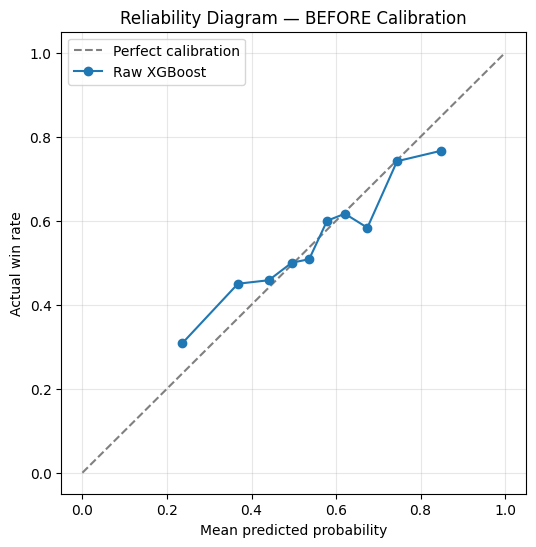

In [35]:
plt.figure(figsize=(6,6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw XGBoost")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual win rate")
plt.title("Reliability Diagram — BEFORE Calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
print("Raw Brier score:", round(brier_score_loss(y_test, raw_probs_test), 4))
print("Raw log loss:", round(log_loss(y_test, raw_probs_test), 4))

Raw Brier score: 0.2322
Raw log loss: 0.6564


In [37]:
try:
  cal_model = CalibratedClassifierCV(FrozenEstimator(raw_model),method="isotonic")
except ImportError:
  cal_model = CalibratedClassifierCV(raw_model,method="isotonic",cv="prefit")

In [38]:
cal_model.fit(X_cal,y_cal)
cal_probs_test = cal_model.predict_proba(X_test)[:, 1]

In [40]:
cal_probs_test = cal_model.predict_proba(X_test)[:, 1]

In [47]:
print("Cal Brier score:", round(brier_score_loss(y_test, cal_probs_test), 4))
print("Cal log loss:", round(log_loss(y_test, cal_probs_test), 4))

Cal Brier score: 0.232
Cal log loss: 0.6833


In [42]:
print("Calibrated probability range:", cal_probs_test.min(), cal_probs_test.max())
print("Count at exact 0.0:", (cal_probs_test == 0.0).sum())
print("Count at exact 1.0:", (cal_probs_test == 1.0).sum())

Calibrated probability range: 0.315315306186676 1.0
Count at exact 0.0: 0
Count at exact 1.0: 10


In [43]:
cal_probs_test_clipped = np.clip(cal_probs_test, 0.01, 0.99)
print("Calibrated log loss (clipped):", round(log_loss(y_test, cal_probs_test_clipped), 4))

Calibrated log loss (clipped): 0.6572


Platt Scaling

In [44]:
try:
  cal_model_platt = CalibratedClassifierCV(FrozenEstimator(raw_model),method="sigmoid")
except ImportError:
    cal_model_platt = CalibratedClassifierCV(raw_model, method="sigmoid", cv="prefit")

In [45]:
cal_model_platt.fit(X_cal, y_cal)
cal_probs_platt = cal_model_platt.predict_proba(X_test)[:, 1]

In [46]:
print("Platt Brier score:", round(brier_score_loss(y_test, cal_probs_platt), 4))
print("Platt log loss:", round(log_loss(y_test, cal_probs_platt), 4))

Platt Brier score: 0.2309
Platt log loss: 0.6536


After Platt Scaling curve

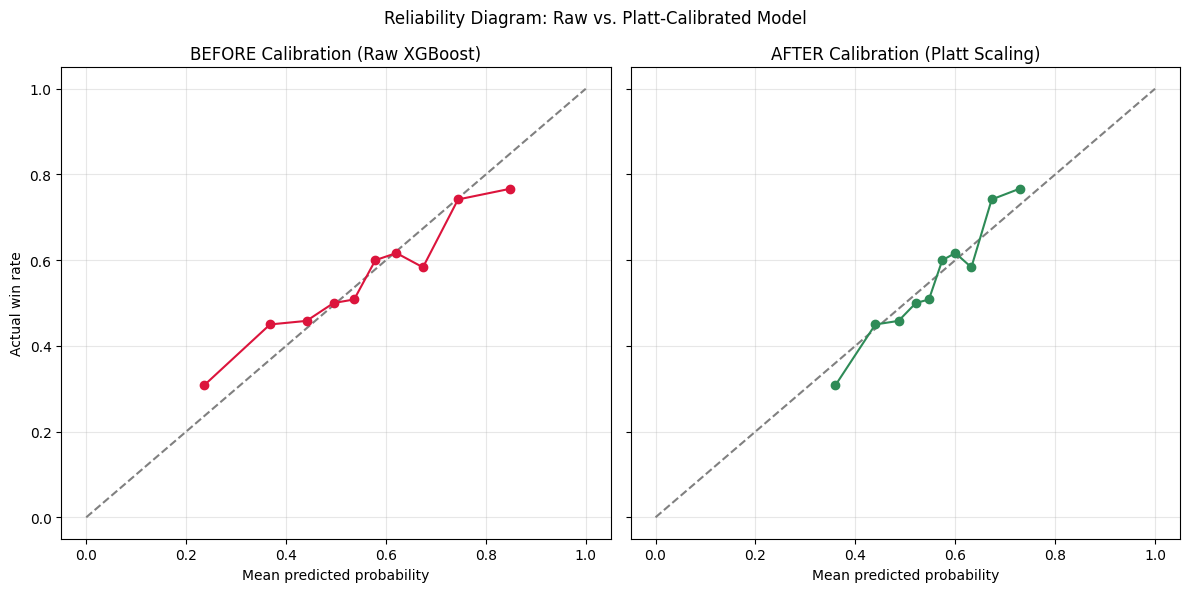

In [48]:
frac_pos_platt, mean_pred_platt = calibration_curve(y_test, cal_probs_platt, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].plot(mean_pred_raw, frac_pos_raw, marker="o", color="crimson")
axes[0].set_title("BEFORE Calibration (Raw XGBoost)")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Actual win rate")
axes[0].grid(alpha=0.3)

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].plot(mean_pred_platt, frac_pos_platt, marker="o", color="seagreen")
axes[1].set_title("AFTER Calibration (Platt Scaling)")
axes[1].set_xlabel("Mean predicted probability")
axes[1].grid(alpha=0.3)

plt.suptitle("Reliability Diagram: Raw vs. Platt-Calibrated Model")
plt.tight_layout()
plt.savefig("reliability_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

Evaluation Matrix

In [50]:
threshold = 0.5
preds = (cal_probs_platt > threshold).astype(int)

In [54]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.60      0.39      0.48       536
           1       0.62      0.79      0.69       664

    accuracy                           0.61      1200
   macro avg       0.61      0.59      0.58      1200
weighted avg       0.61      0.61      0.60      1200



In [56]:
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print(f"False positives (told to fight, actually lost):        {fp}  <- wasted merchant effort")
print(f"False negatives (told to drop, actually would've won): {fn}  <- lost recoverable revenue")

False positives (told to fight, actually lost):        325  <- wasted merchant effort
False negatives (told to drop, actually would've won): 139  <- lost recoverable revenue


In [57]:
FP_COST_PER_CASE = 150  # Rs, assumed merchant staff time/effort per wrongly-fought case

fn_mask = (preds == 0) & (y_test.values == 1)
fn_indices = y_test.index[fn_mask]
avg_order_value_fn = df.loc[fn_indices, "order_value"].mean() if fn_mask.sum() > 0 else 0

total_fp_cost = fp * FP_COST_PER_CASE
total_fn_cost = avg_order_value_fn * fn

print(f"Estimated wasted-effort cost from false positives: Rs {total_fp_cost:,.0f}")
print(f"Estimated lost revenue from false negatives:        Rs {total_fn_cost:,.0f}")

Estimated wasted-effort cost from false positives: Rs 48,750
Estimated lost revenue from false negatives:        Rs 174,463
